# YOLO + TripoSR: Görselden 3D Modele Pipeline (Hibrit: Yerel + Uzak)

Önceki sürüm TripoSR'ı bilgisayarında yerelde çalıştırmaya çalışıyordu, ama
`torchmcubes` ve `xatlas` gibi paketler C++ derleyici gerektiriyor ve
bu makinede derleme araçları (cmake / Xcode Command Line Tools vb.) eksik
olduğu için sürekli kurulum hatası veriyordu.

Bu sürüm farklı bir yol izliyor:
1. **YOLO** ile nesne tespiti ve kırpma -- tamamen yerelde, sorunsuz çalışır.
2. **TripoSR** ile 3D üretim -- yerelde kurmak yerine, Hugging Face'in
   barındırdığı `stabilityai/TripoSR` Space'ine görseli gönderip sonucu
   geri alıyoruz (`gradio_client` kütüphanesiyle). Bu, hiçbir C++
   derlemesi gerektirmez, sadece internet bağlantısı gerekir.

> Not: Bu Space herkese açık ve ücretsizdir ama paylaşılan bir kaynaktır --
> yoğun saatlerde biraz kuyrukta bekleyebilirsin. Bu normaldir.

## 1) Kurulum

Burada hiçbir C++ derlemesi gerekmiyor -- tüm paketler hazır (prebuilt) wheel olarak kurulur, bu yüzden önceki hatalarla karşılaşmazsın.

In [1]:
!pip install -q ultralytics pillow numpy gradio_client

## 2) Ayarlar

Girdi görselini ve parametreleri buradan değiştir.

In [2]:
import os

IMAGE_PATH = "apple.jpeg"        # kendi görselinin yolunu buraya yaz
OUTPUT_DIR = "output"
YOLO_MODEL = "yolov8n.pt"       # ultralytics önceden eğitilmiş model
TARGET_CLASS = None              # örn: "chair" -- belirtmezsen en güvenli tespit seçilir
CONF_THRESHOLD = 0.25
PADDING = 0.10                   # kutu boyutunun oranı olarak kenar payı

REMOVE_BACKGROUND = True         # TripoSR Space'i arka planı kendi tarafında temizler
FOREGROUND_RATIO = 0.85          # 0.5-1.0 arası; nesnenin kare içindeki kaplama oranı
MC_RESOLUTION = 256              # marching cubes çözünürlüğü (32-320 arası, artırırsan kalite artar süre uzar)

os.makedirs(OUTPUT_DIR, exist_ok=True)

## 3) YOLO ile tespit ve kırpma

Görseldeki hedef nesneyi tespit edip kırpıyoruz.

[YOLO] Model yükleniyor: yolov8n.pt
[YOLO] Tespit çalıştırılıyor: apple.jpeg

image 1/1 /Users/rumeysaelvanoglu/deepLearningNotebook/apple.jpeg: 640x640 1 apple, 38.9ms
Speed: 1.4ms preprocess, 38.9ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)
[YOLO] Seçilen tespit: 'apple' (güven: 0.88)
[YOLO] Kırpılmış görsel kaydedildi: output/cropped_object.png


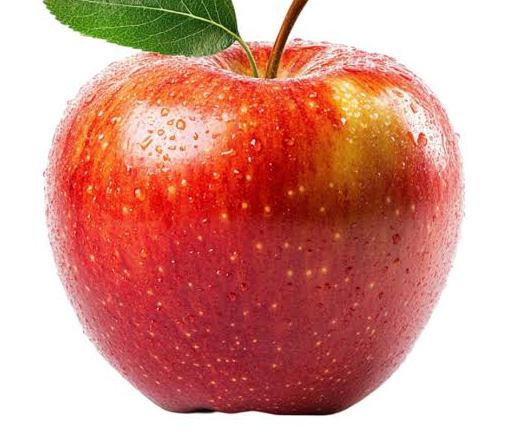

In [3]:
from ultralytics import YOLO
from PIL import Image
import numpy as np

def detect_and_crop(image_path, yolo_model_path, target_class, conf, padding, out_dir):
    print(f"[YOLO] Model yükleniyor: {yolo_model_path}")
    model = YOLO(yolo_model_path)

    print(f"[YOLO] Tespit çalıştırılıyor: {image_path}")
    results = model(image_path, conf=conf)[0]

    if results.boxes is None or len(results.boxes) == 0:
        raise RuntimeError("Görselde hiçbir nesne tespit edilemedi. CONF_THRESHOLD değerini düşürmeyi deneyebilirsin.")

    names = results.names
    boxes = results.boxes.xyxy.cpu().numpy()
    confs = results.boxes.conf.cpu().numpy()
    classes = results.boxes.cls.cpu().numpy().astype(int)

    if target_class:
        candidates = [i for i, c in enumerate(classes) if names[c].lower() == target_class.lower()]
        if not candidates:
            available = sorted(set(names[c] for c in classes))
            raise RuntimeError(
                f"'{target_class}' sınıfı bu görselde bulunamadı. "
                f"Tespit edilen sınıflar: {available}"
            )
        chosen_idx = max(candidates, key=lambda i: confs[i])
    else:
        chosen_idx = int(np.argmax(confs))

    box = boxes[chosen_idx]
    label = names[classes[chosen_idx]]
    score = confs[chosen_idx]
    print(f"[YOLO] Seçilen tespit: '{label}' (güven: {score:.2f})")

    img = Image.open(image_path).convert("RGB")
    w, h = img.size
    x1, y1, x2, y2 = box
    box_w, box_h = x2 - x1, y2 - y1
    pad_x, pad_y = box_w * padding, box_h * padding

    x1 = max(0, x1 - pad_x)
    y1 = max(0, y1 - pad_y)
    x2 = min(w, x2 + pad_x)
    y2 = min(h, y2 + pad_y)

    cropped = img.crop((x1, y1, x2, y2))
    crop_path = os.path.join(out_dir, "cropped_object.png")
    cropped.save(crop_path)
    print(f"[YOLO] Kırpılmış görsel kaydedildi: {crop_path}")
    return crop_path, label

crop_path, label = detect_and_crop(
    IMAGE_PATH, YOLO_MODEL, TARGET_CLASS, CONF_THRESHOLD, PADDING, OUTPUT_DIR
)

# Kırpılmış görseli notebook içinde göster
Image.open(crop_path)

## 4) TripoSR ile 3D mesh üretimi (uzaktan, Hugging Face Space üzerinden)

Kırpılmış görseli `stabilityai/TripoSR` Space'ine gönderiyoruz. İşlem iki
adımdan oluşur: `/preprocess` (arka plan temizleme + ölçekleme) ve
`/generate` (asıl 3D üretim). Bu hücre biraz zaman alabilir -- Space
meşgulse kuyrukta bekleyebilirsin, bu normaldir.

### 4a) (Tanı amaçlı) API imzasını kontrol et

Hugging Face Space'lerinin API'si zaman içinde değişebilir. Bu hücre,
Space'in şu an gerçekte beklediği parametreleri gösterir -- bir sonraki
hücrede kullandığımız parametrelerle uyuşmazlık varsa burada görünür.

In [4]:
from gradio_client import Client

client = Client("stabilityai/TripoSR")
client.view_api()

/Users/rumeysaelvanoglu/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded as API: https://stabilityai-triposr.hf.space
Client.predict() Usage Info
---------------------------
Named API endpoints: 3

 - predict(input_image, api_name="/check_input_image") -> 
    Parameters:
     - [Image] input_image: filepath (required)  
    Returns:
     - None

 - predict(input_image, remove_background, foreground_ratio, api_name="/preprocess") -> processed_image
    Parameters:
     - [Image] input_image: filepath (required)  
     - [Checkbox] remove_background: bool (required)  
     - [Slider] foreground_ratio: float (required)  (numeric value between 0.5 and 1.0) 
    Returns:
     - [Image] processed_image: filepath 

 - predict(processed_image, marching_cubes_resolution, api_name="/generate") -> (output_model_obj_format, output_model_glb_format)
    Parameters:
     - [Image] processed_image: filepath (required)  
     - [Slider] marching_cubes_resolution: float (required)  (numeric value between 32 and 320) 
    Returns:
     - [Model3d] output_model_obj_fo

### 4b) Görseli gönder ve 3D mesh üret

Eğer bu hücre yine de belirsiz bir `AppError` verirse (Space kendi hatasının
detayını bize göstermiyor), en güvenilir çözüm Space'i kendi Hugging Face
hesabına **kopyalamak (duplicate)**: `stabilityai/TripoSR` sayfasında sağ üstteki
"⋮" menüsünden "Duplicate this Space" seç. Kendi kopyanda hatayı tam olarak
görebilir ve (varsa) kuyruk/kota sorunlarından etkilenmezsin.

In [5]:
import shutil
from gradio_client import handle_file

print("[TripoSR] Görsel ön işleniyor (arka plan temizleme)...")
processed_image = client.predict(
    handle_file(crop_path),
    REMOVE_BACKGROUND,
    FOREGROUND_RATIO,
    api_name="/preprocess",
)

print("[TripoSR] 3D mesh üretiliyor (bu adım biraz sürebilir)...")
result = client.predict(
    handle_file(processed_image) if isinstance(processed_image, str) else processed_image,
    MC_RESOLUTION,
    api_name="/generate",
)


def extract_mesh_path(result):
    """Gradio Space'inin döndürdüğü çıktıdan mesh dosyasının yolunu bulur.
    Farklı Space sürümleri farklı formatlarda döndürebildiği için esnek davranır."""
    items = result if isinstance(result, (list, tuple)) else [result]
    for item in items:
        path = item.get("path") if isinstance(item, dict) else item
        if isinstance(path, str) and path.lower().endswith((".glb", ".obj", ".ply")):
            return path
    raise RuntimeError(f"Beklenen mesh dosyası bulunamadı. API çıktısı: {result}")


remote_mesh_path = extract_mesh_path(result)
mesh_path = os.path.join(OUTPUT_DIR, "output_model" + os.path.splitext(remote_mesh_path)[1])
shutil.copy(remote_mesh_path, mesh_path)
print(f"[TripoSR] 3D model kaydedildi: {mesh_path}")

[TripoSR] Görsel ön işleniyor (arka plan temizleme)...
[TripoSR] 3D mesh üretiliyor (bu adım biraz sürebilir)...
[TripoSR] 3D model kaydedildi: output/output_model.obj


## 5) 3D modeli notebook içinde görüntüle

In [9]:
import trimesh
import plotly.graph_objects as go

mesh = trimesh.load(mesh_path, force="mesh")   # mesh_path = TripoSR'ın ürettiği .glb dosyasının yolu

fig = go.Figure(data=[
    go.Mesh3d(
        x=mesh.vertices[:, 0],
        y=mesh.vertices[:, 1],
        z=mesh.vertices[:, 2],
        i=mesh.faces[:, 0],
        j=mesh.faces[:, 1],
        k=mesh.faces[:, 2],
        color="lightgray",
        opacity=1.0,
    )
])
fig.update_layout(scene=dict(aspectmode="data"), margin=dict(l=0, r=0, t=0, b=0), height=500)
fig.show()

## 6) Sonuç

In [7]:
print("Tamamlandı.")
print(f"  Tespit edilen nesne : {label}")
print(f"  Kırpılmış görsel    : {crop_path}")
print(f"  3D model            : {mesh_path}")

# Colab kullanıyorsan dosyayı indirmek için:
# from google.colab import files
# files.download(mesh_path)

Tamamlandı.
  Tespit edilen nesne : apple
  Kırpılmış görsel    : output/cropped_object.png
  3D model            : output/output_model.obj
